In [1]:
# import necessary libraries
import pandas as pd
import os
import re
import glob

import json
from datetime import datetime
import matplotlib.pyplot as plt
from collections import defaultdict
from openpyxl import load_workbook, Workbook


### Load Mappings

In [55]:
# --- Constants ---
MONTH = "July 2026"
FOLDER_PATH = f"statements/{MONTH}"
CATEGORY_KEYWORDS_FILE = "category_keywords.json"
EXPENSE_CATEGORIES_FILE = "expense_categories.json"
GLOBAL_EXPENSE_CATEGORIES_FILE = "expense_categories_global.json"
PREDICTED_OUTPUT_FILE = "statements_with_predicted_categories.csv"

# Define the cleaned subfolder
CLEANED_DIR = os.path.join(FOLDER_PATH, "cleaned")
os.makedirs(CLEANED_DIR, exist_ok=True)

RENT = 1800.00
STATEMENTS_SUMMARY_FILE = f"statements/{MONTH}/monthly_summary.csv"


In [11]:
# --- 1. Load Keyword Map ---
with open(CATEGORY_KEYWORDS_FILE, "r") as f:
    category_keywords = json.load(f)

# --- 2. Load Main & Global Category Mappings ---
if os.path.exists(EXPENSE_CATEGORIES_FILE):
    with open(EXPENSE_CATEGORIES_FILE, "r") as f:
        expense_map = json.load(f)
else:
    expense_map = {}

if os.path.exists(GLOBAL_EXPENSE_CATEGORIES_FILE):
    with open(GLOBAL_EXPENSE_CATEGORIES_FILE, "r") as f:
        expense_map_global = json.load(f)
else:
    expense_map_global = {}

# person map
person_map = {
    'guneet': ['gunnu', 'guneet'],
    'hardik': ['hardik', 'honey']
}

### Declare helper functions

In [12]:
# --- 4. Helper Functions ---
def standardize_amounts(df, is_credit_card):
    """
    For credit card files, make all 'Credit' transactions negative (expense standardization).
    For all others, leave as is.
    """
    if is_credit_card:
        # For rows now marked as "Credit", ensure Amount is negative
        mask = df['Type of Transaction'].str.strip().str.lower() == 'credit'
        # Make amount negative (preserve zeros and already-negative)
        df.loc[mask, 'Amount'] = -df.loc[mask, 'Amount'].abs()
    return df

def swap_credit_debit_types(df):
    mapping = {'credit': 'Debit', 'debit': 'Credit'}
    before = df['Type of Transaction'].unique()
    df['Type of Transaction'] = df['Type of Transaction'].apply(
        lambda x: mapping.get(str(x).strip().lower(), x)
    )
    after = df['Type of Transaction'].unique()
    print(f"Swapped types: before={list(before)}, after={list(after)}")
    return df

def reverse_polarity(df):
    """
    For all rows:
    - If Amount < 0: make positive (expense)
    - If Amount > 0: make negative (credit/income/payment)
    """
    before = df['Amount'].copy()
    df['Amount'] = df['Amount'].apply(lambda x: abs(x) if x < 0 else -abs(x) if x > 0 else 0)
    print("Sample before:", before.head().tolist())
    print("Sample after:", df['Amount'].head().tolist())
    return df

def clean_key(row):
    desc = re.sub(r'\s+', '_', str(row['Description']).strip())
    sub = re.sub(r'\s+', '_', str(row['Sub-description']).strip())
    return f"{desc}|{sub}"

def predict_category(key):
    merchant = key.lower().replace('_', ' ')
    for category, keywords in category_keywords.items():
        for kw in keywords:
            if kw in merchant:
                return category
    return ""

def assign_category(row):
    key = clean_key(row)
    # Priority: internal mapping, global mapping, prediction, empty
    if key in expense_map and expense_map[key]:
        return expense_map[key]
    elif key in expense_map_global and expense_map_global[key]:
        expense_map[key] = expense_map_global[key]
        return expense_map_global[key]
    else:
        pred = predict_category(key)
        expense_map[key] = pred  # Save prediction (may be empty string)
        return pred
    
# Example usage (call after your category logic):
def is_card_payment(row):
    payment_keywords = ['payment', 'bill payment', 'credit card payment', 'payment to', 'paid']
    desc = str(row['Description']).lower()
    return any(kw in desc for kw in payment_keywords)


### Clean and save the files with new suffix

In [14]:
CLEANED_SUFFIX = datetime.now().strftime("%Y%m%d") + "_cleaned.csv"
cleaned_files = []

def read_if_exists(path):
    return pd.read_csv(path) if os.path.exists(path) else None

for fname in os.listdir(FOLDER_PATH):
    if not fname.lower().endswith('.csv') or '_cleaned' in fname.lower():
        continue

    base_name = fname.rsplit('.csv', 1)[0]
    cleaned_candidates = [f for f in os.listdir(CLEANED_DIR)
                          if f.startswith(base_name) and f.endswith('_cleaned.csv')]
    if cleaned_candidates:
        # Use the most recent cleaned file for this base name
        cleaned_candidates = sorted(cleaned_candidates, key=lambda x: os.path.getmtime(os.path.join(CLEANED_DIR, x)), reverse=True)
        cleaned_path = os.path.join(CLEANED_DIR, cleaned_candidates[0])
        df_cleaned = pd.read_csv(cleaned_path)
    else:
        df_cleaned = None

    # Load downloaded (to-be-cleaned) file
    downloaded_path = os.path.join(FOLDER_PATH, fname)
    df_downloaded = pd.read_csv(downloaded_path)

    # --- Match by keys, for example: Date, Description, Amount ---
    # 1. Remove "Type of Transaction" from merge keys (because it changes)
    merge_keys = [k for k in ['Date', 'Description', 'Amount'] if k in df_downloaded.columns and k in (df_cleaned.columns if df_cleaned is not None else [])]

    if df_cleaned is not None and merge_keys:
        merged = pd.merge(
            df_cleaned, df_downloaded,
            how='outer',
            on=merge_keys,
            suffixes=('', '_dl')
        )

        # Update/copy-down fields from downloaded where cleaned is missing
        for col in df_downloaded.columns:
            if col in merge_keys:
                continue
            if col in merged.columns and f"{col}_dl" in merged.columns:
                merged[col] = merged[col].combine_first(merged[f"{col}_dl"])
                merged.drop(f"{col}_dl", axis=1, inplace=True)
            elif f"{col}_dl" in merged.columns:
                merged[col] = merged[f"{col}_dl"]
                merged.drop(f"{col}_dl", axis=1, inplace=True)

        # --- Deduplicate: keep cleaned row (has category/personal), prefer those with 'Category' not null ---
        merged['has_category'] = merged['Category'].notnull()
        merged = merged.sort_values('has_category', ascending=False)
        merged = merged.drop_duplicates(subset=merge_keys, keep='first')
        merged = merged.drop(columns=['has_category'])
        merged.reset_index(drop=True, inplace=True)
        df_final = merged
    else:
        df_final = df_downloaded

    # Drop 'Filter' column if it exists
    df_final = df_final.drop(columns=['Filter'], errors='ignore')
    # You can continue your processing for swapping credit/debit, standardizing, assigning categories, etc. on df_final
    # --- (do your assign_category, swap_credit_debit_types, standardize_amounts here if needed) ---
    # For example:
    fname_lower = fname.lower()
    is_credit = 'credit' in fname_lower
    person = None
    if any(fname_lower.startswith(prefix) for prefix in person_map['guneet']):
        person = 'guneet'
    elif any(fname_lower.startswith(prefix) for prefix in person_map['hardik']):
        person = 'hardik'

    df_final['Person'] = person.capitalize() if person else ""
    if is_credit:
        df_final = reverse_polarity(df_final)

    if 'Category' not in df_final.columns:
        df_final['Category'] = df_final.apply(assign_category, axis=1)
        with open(EXPENSE_CATEGORIES_FILE, "w") as f:
            json.dump(expense_map, f, indent=2)
    if 'personal' not in df_final.columns:
        df_final['personal'] = 0
    else:
        df_final['personal'] = df_final['personal'].fillna(0)
        df_final.loc[df_final['personal'].astype(str).str.strip() == '', 'personal'] = 0
        df_final['personal'] = df_final['personal'].astype(int)

    # Save as new cleaned file with date
    new_cleaned_fname = base_name + f'_{CLEANED_SUFFIX}'
    cleaned_path = os.path.join(CLEANED_DIR, new_cleaned_fname)
    df_final.to_csv(cleaned_path, index=False)
    print(f"Cleaned file saved: {cleaned_path}")

# Finally, delete all old cleaned files except the newly created ones
for f in os.listdir(CLEANED_DIR):
    if f.endswith('_cleaned.csv') and not f.endswith(CLEANED_SUFFIX):
        os.remove(os.path.join(CLEANED_DIR, f))
        print(f"Deleted old cleaned file: {f}")



Sample before: [17.81, 3.35, 36.71, 20.57, 1.12]
Sample after: [-17.81, -3.35, -36.71, -20.57, -1.12]
Cleaned file saved: statements/Aug 2026/cleaned/amex_credit_honey_20260829_cleaned.csv
Sample before: [6.27, 23.02, -526.94, 65.31, 23.82]
Sample after: [-6.27, -23.02, 526.94, -65.31, -23.82]
Cleaned file saved: statements/Aug 2026/cleaned/Gunnu_credit_1722_20260829_cleaned.csv
Cleaned file saved: statements/Aug 2026/cleaned/Gunnu_debit_3724_20260829_cleaned.csv
Cleaned file saved: statements/Aug 2026/cleaned/honey_debit_savings_20260829_cleaned.csv
Sample before: [16.32, 8.39, 24.28, 36.7, 59.92]
Sample after: [-16.32, -8.39, -24.28, -36.7, -59.92]
Cleaned file saved: statements/Aug 2026/cleaned/Scene_Visa_honey_credit_20260829_cleaned.csv
Sample before: [3.12, 24.32, 2.79, 10.5, 8.95]
Sample after: [-3.12, -24.32, -2.79, -10.5, -8.95]
Cleaned file saved: statements/Aug 2026/cleaned/Gunnu_credit_9014_20260829_cleaned.csv


### Read from cleaned folder and start processing

In [56]:
# List all cleaned CSVs in the cleaned subfolder
all_cleaned = sorted(
    [f for f in os.listdir(CLEANED_DIR) if f.endswith('_cleaned.csv')],
    key=lambda x: os.path.getmtime(os.path.join(CLEANED_DIR, x)),
    reverse=True
)

dfs = {'guneet': [], 'hardik': []}

for fname in all_cleaned:
    fname_lower = fname.lower()
    paid_by = None
    if any(fname_lower.startswith(prefix) for prefix in person_map['guneet']):
        person = 'guneet'
        paid_by = 'Guneet'
    elif any(fname_lower.startswith(prefix) for prefix in person_map['hardik']):
        person = 'hardik'
        paid_by = 'Hardik'
    else:
        continue
    path = os.path.join(CLEANED_DIR, fname)
    print(f"Loading cleaned file for {person.capitalize()}: {path}")
    df = pd.read_csv(path)
    df['PaidBy'] = paid_by  # Assign PaidBy column
    dfs[person].append(df)

# Combine all files for each person
for key in dfs:
    if dfs[key]:
        print(f"Combining {len(dfs[key])} cleaned files for {key.capitalize()}...")
        dfs[key] = pd.concat(dfs[key], ignore_index=True)
    else:
        dfs[key] = pd.DataFrame()
        print(f"No cleaned files for {key.capitalize()}.")

# Combine both into a single DataFrame for processing
df = pd.concat([dfs['guneet'], dfs['hardik']], ignore_index=True)
print(f"\nCombined DataFrame shape: {df.shape}")


Loading cleaned file for Hardik: statements/July 2026/cleaned/Honey_credit_Scene_Visa_card_3189 2_20260803_cleaned.csv
Loading cleaned file for Hardik: statements/July 2026/cleaned/Honey_debit_0282_20260803_cleaned.csv
Loading cleaned file for Hardik: statements/July 2026/cleaned/Honey_credit_Amex_Card_0314 2_20260803_cleaned.csv
Loading cleaned file for Guneet: statements/July 2026/cleaned/gunnu_debit_3724_20260803_cleaned.csv
Loading cleaned file for Guneet: statements/July 2026/cleaned/gunnu_credit_9014_20260803_cleaned.csv
Loading cleaned file for Guneet: statements/July 2026/cleaned/gunnu_credit_8012_20260803_cleaned.csv
Loading cleaned file for Guneet: statements/July 2026/cleaned/gunnu_credit_1722_20260803_cleaned.csv
Combining 4 cleaned files for Guneet...
Combining 3 cleaned files for Hardik...

Combined DataFrame shape: (143, 11)


In [57]:
# Add/fix 'personal' column if missing or blank
if 'personal' not in df.columns:
    df['personal'] = 0
else:
    df['personal'] = df['personal'].fillna(0)
    df.loc[df['personal'].astype(str).str.strip() == '', 'personal'] = 0
    df['personal'] = df['personal'].astype(int)

In [58]:
df['Amount'] = df['Amount'].astype(float)
df['Date'] = pd.to_datetime(df['Date'])

# Expense = negative debit, Income = positive credit
df['Expense'] = df.apply(lambda row: abs(row['Amount']) if row['Type of Transaction'] == 'Debit' and row['Amount'] < 0 else 0, axis=1)
df['Income'] = df.apply(lambda row: row['Amount'] if row['Type of Transaction'] == 'Credit' and row['Amount'] > 0 else 0, axis=1)
df_valid = df[df['personal'] != -1]

print('Total Money Out:', df_valid['Expense'].sum())
print('Total Money In:', df_valid['Income'].sum())

Total Money Out: 7036.09
Total Money In: 414.25


Ensure the json is in format desc_a|sub_desc_a_b_c

In [59]:
# --- 5. Apply and Save any new categories back to the json ---
df_valid['Category'] = df_valid.apply(assign_category, axis=1)
with open(EXPENSE_CATEGORIES_FILE, "w") as f:
    json.dump(expense_map, f, indent=2)

/var/folders/wz/fw947r3x7rs9l5xsy_pbzz4m0000gn/T/ipykernel_11833/2383222022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['Category'] = df_valid.apply(assign_category, axis=1)


Final Calculation of per person owed amount

In [60]:
# Calculate how much each person actually paid (by PaidBy for *all* rows)
total_expense = df_valid.groupby('PaidBy')['Expense'].sum().to_dict() 
total_income = df_valid.groupby('PaidBy')['Income'].sum().to_dict()
actual_paid = (df_valid.groupby('PaidBy')[['Expense','Income']]
               .sum()
               .eval('Expense - Income')
               .to_dict())

print("\nActual Paid Summary:", actual_paid)


# Each person's "should pay" (personal expenses assigned to them, shared = half)
should_pay = {}
for person, code in [('Guneet', 1), ('Hardik', 2)]:
    personal_expense = df_valid[(df_valid['personal'] == code)]['Expense'].sum()
    shared_expense = df_valid[df_valid['personal'] == 0]['Expense'].sum() / 2

    print(f"{person} - Personal Expense: {personal_expense}, Shared Expense: {shared_expense}")
    personal_income = df_valid[(df_valid['personal'] == code)]['Income'].sum()
    shared_income = df_valid[df_valid['personal'] == 0]['Income'].sum() / 2

    print(f"{person} - Personal Income: {personal_income}, Shared Income: {shared_income}")
    should_pay[person] = personal_expense + shared_expense - (personal_income + shared_income)

print("Should Pay Summary:", should_pay)

# For persons not present in PaidBy (possible if, say, Guneet has no paid entries), set to 0
guneet_paid = actual_paid.get('Guneet', 0)
hardik_paid = actual_paid.get('Hardik', 0)
guneet_should = should_pay.get('Guneet', 0)
hardik_should = should_pay.get('Hardik', 0)

# The difference is the net owed: positive means Hardik owes Guneet, negative means Guneet owes Hardik
net_settle = round(guneet_paid - guneet_should, 2)

print("\nSummary:")
print(f"Guneet paid: ${guneet_paid:.2f} (should pay: ${guneet_should:.2f})")
print(f"Hardik paid: ${hardik_paid:.2f} (should pay: ${hardik_should:.2f})")
print(f"Shared total: ${2*(shared_expense-shared_income):.2f}")

if net_settle > 0:
    print(f"Hardik owes Guneet ${net_settle}")
elif net_settle < 0:
    print(f"Guneet owes Hardik ${-net_settle}")
else:
    print("All settled up!")


Actual Paid Summary: {'Guneet': 2514.73, 'Hardik': 4107.110000000001}
Guneet - Personal Expense: 223.01, Shared Expense: 1809.8399999999997
Guneet - Personal Income: 7.63, Shared Income: 203.31
Hardik - Personal Expense: 3193.4, Shared Expense: 1809.8399999999997
Hardik - Personal Income: 0.0, Shared Income: 203.31
Should Pay Summary: {'Guneet': np.float64(1821.9099999999996), 'Hardik': np.float64(4799.929999999999)}

Summary:
Guneet paid: $2514.73 (should pay: $1821.91)
Hardik paid: $4107.11 (should pay: $4799.93)
Shared total: $3213.06
Hardik owes Guneet $692.82


In [61]:
# --- Salary-Based Shared Expense Split ---
guneet_salary = 3073*2  # Set Guneet's salary here
hardik_salary = 3684*2  # Set Hardik's salary here

total_salary = guneet_salary + hardik_salary
guneet_ratio = guneet_salary / total_salary
hardik_ratio = hardik_salary / total_salary

shared_expense_total = df_valid[df_valid['personal'] == 0]['Expense'].sum()
shared_income_total  = df_valid[df_valid['personal'] == 0]['Income'].sum()
shared_net = shared_expense_total - shared_income_total

guneet_shared_share = round(shared_net * guneet_ratio, 2)
hardik_shared_share = round(shared_net * hardik_ratio, 2)

guneet_personal_net = df_valid[df_valid['personal'] == 1]['Expense'].sum() - df_valid[df_valid['personal'] == 1]['Income'].sum()
hardik_personal_net = df_valid[df_valid['personal'] == 2]['Expense'].sum() - df_valid[df_valid['personal'] == 2]['Income'].sum()

# BEFORE: equal 50/50 split
guneet_should_before = round(guneet_personal_net + (shared_net / 2), 2)
hardik_should_before = round(hardik_personal_net + (shared_net / 2), 2)
net_before = round(guneet_paid - guneet_should_before, 2)

# AFTER: salary-ratio split
guneet_should_after = round(guneet_personal_net + guneet_shared_share, 2)
hardik_should_after = round(hardik_personal_net + hardik_shared_share, 2)
net_after = round(guneet_paid - guneet_should_after, 2)

print(f"Salaries  →  Guneet: ${guneet_salary:,}  |  Hardik: ${hardik_salary:,}")
print(f"Ratios    →  Guneet: {guneet_ratio:.1%}  |  Hardik: {hardik_ratio:.1%}")
print(f"Shared Net Total: ${shared_net:,.2f}")
print()
print("─" * 50)
print("BEFORE  (Equal 50/50 Split):")
print(f"  Guneet paid: ${guneet_paid:.2f}  |  should pay: ${guneet_should_before:.2f}")
print(f"  Hardik paid: ${hardik_paid:.2f}  |  should pay: ${hardik_should_before:.2f}")
if net_before > 0:
    print(f"  → Hardik owes Guneet ${net_before:.2f}")
elif net_before < 0:
    print(f"  → Guneet owes Hardik ${-net_before:.2f}")
else:
    print("  → All settled up!")
print()
print("─" * 50)
print("AFTER  (Salary-Ratio Split):")
print(f"  Guneet pays {guneet_ratio:.1%} of shared  →  ${guneet_shared_share:.2f}")
print(f"  Hardik pays {hardik_ratio:.1%} of shared  →  ${hardik_shared_share:.2f}")
print(f"  Guneet paid: ${guneet_paid:.2f}  |  should pay: ${guneet_should_after:.2f}")
print(f"  Hardik paid: ${hardik_paid:.2f}  |  should pay: ${hardik_should_after:.2f}")
if net_after > 0:
    print(f"  → Hardik owes Guneet ${net_after:.2f}")
elif net_after < 0:
    print(f"  → Guneet owes Hardik ${-net_after:.2f}")
else:
    print("  → All settled up!")

Salaries  →  Guneet: $6,146  |  Hardik: $7,368
Ratios    →  Guneet: 45.5%  |  Hardik: 54.5%
Shared Net Total: $3,213.06

──────────────────────────────────────────────────
BEFORE  (Equal 50/50 Split):
  Guneet paid: $2514.73  |  should pay: $1821.91
  Hardik paid: $4107.11  |  should pay: $4799.93
  → Hardik owes Guneet $692.82

──────────────────────────────────────────────────
AFTER  (Salary-Ratio Split):
  Guneet pays 45.5% of shared  →  $1461.26
  Hardik pays 54.5% of shared  →  $1751.80
  Guneet paid: $2514.73  |  should pay: $1676.64
  Hardik paid: $4107.11  |  should pay: $4945.20
  → Hardik owes Guneet $838.09


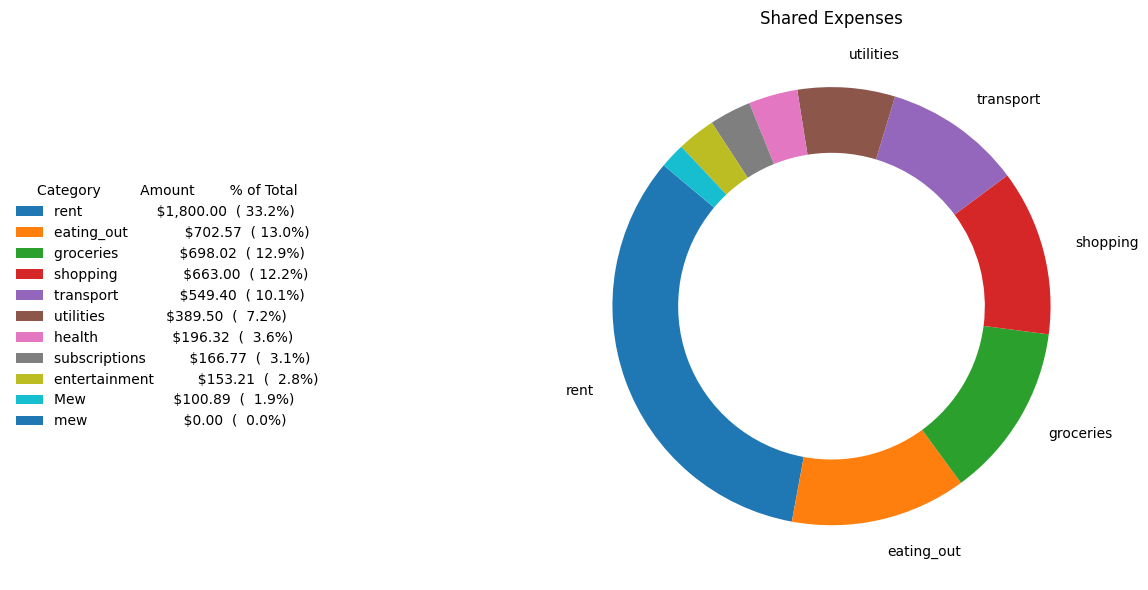

Saved chart: statements/July 2026/cleaned/shared_expenses_pie-chart.png

Shared Expenses:
Category
rent             1800.00
eating_out        702.57
groceries         698.02
shopping          663.00
transport         549.40
utilities         389.50
health            196.32
subscriptions     166.77
entertainment     153.21
Mew               100.89
mew                 0.00
Name: Expense, dtype: float64
Grand Total: $5,419.68



<Figure size 640x480 with 0 Axes>

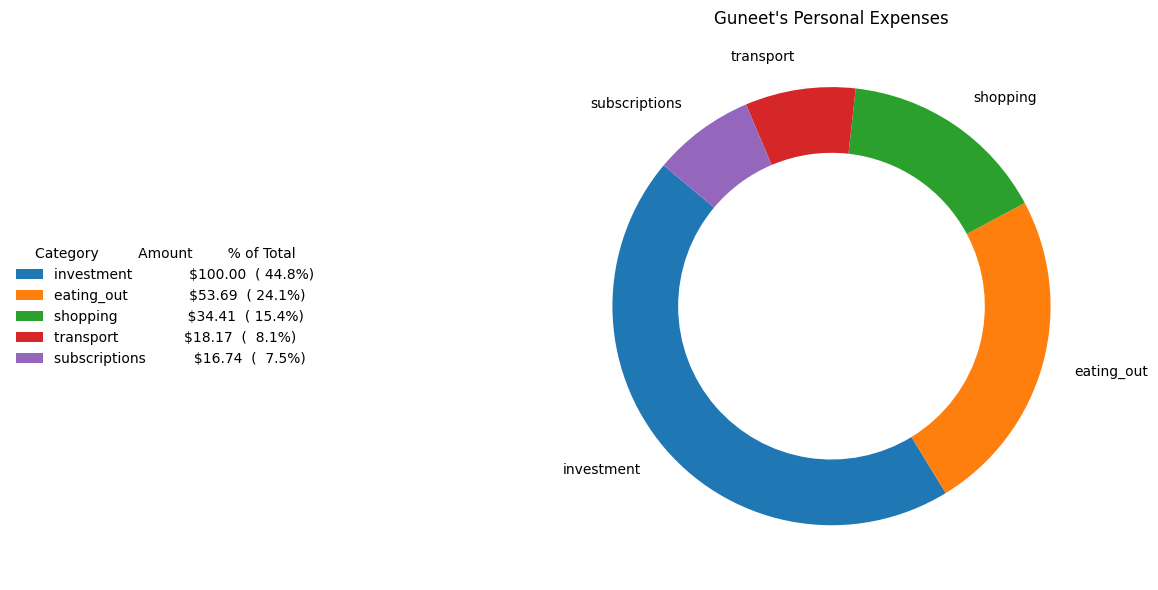

Saved chart: statements/July 2026/cleaned/guneet's_personal_expenses_pie-chart.png

Guneet's Personal Expenses:
Category
investment       100.00
eating_out        53.69
shopping          34.41
transport         18.17
subscriptions     16.74
Name: Expense, dtype: float64
Grand Total: $223.01



<Figure size 640x480 with 0 Axes>

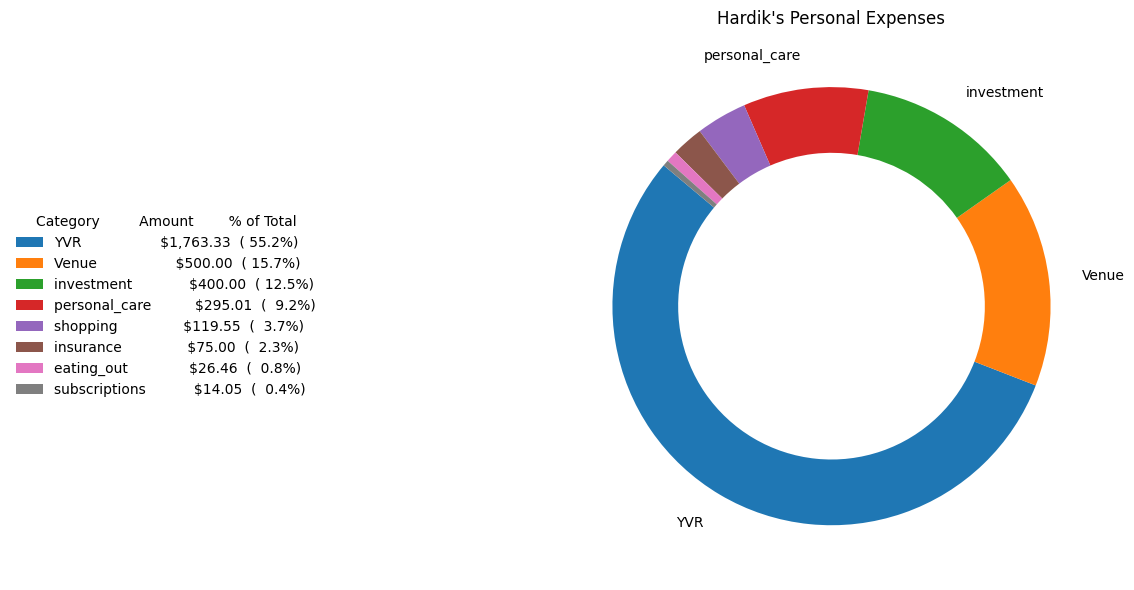

Saved chart: statements/July 2026/cleaned/hardik's_personal_expenses_pie-chart.png

Hardik's Personal Expenses:
Category
YVR              1763.33
Venue             500.00
investment        400.00
personal_care     295.01
shopping          119.55
insurance          75.00
eating_out         26.46
subscriptions      14.05
Name: Expense, dtype: float64
Grand Total: $3,193.40


Grand totals: 
Guneet: $223.01 + $5,419.68/2 = $2,932.85
Hardik: $3,193.40 + $5,419.68/2 = $5,903.24


<Figure size 640x480 with 0 Axes>

In [62]:
import matplotlib.pyplot as plt

RENT = 1800 # Set your rent value

exclude_cats = ['transfer', 'income']

chart_configs = [
    {"title": "Shared Expenses",      "personal_code": 0},
    {"title": "Guneet's Personal Expenses", "personal_code": 1},
    {"title": "Hardik's Personal Expenses", "personal_code": 2}
]

grand_totals = {}

for config in chart_configs:
    # Filter data for this category
    mask = (df['personal'] == config["personal_code"]) & (~df['Category'].isin(exclude_cats))
    data = df[mask]
    category_totals = data.groupby('Category')['Expense'].sum().sort_values(ascending=False)
    # Add rent for shared only
    if config["personal_code"] == 0:
        if 'rent' in category_totals:
            category_totals['rent'] += RENT
        else:
            category_totals['rent'] = RENT
        category_totals = category_totals.sort_values(ascending=False)
    if category_totals.empty:
        print(f"No data for {config['title']}.")
        continue
    total = category_totals.sum()
    percents = category_totals / total * 100
    # Only show label if the percent is >= 5%
    labels = [cat if perc >= 5 else '' for cat, perc in zip(category_totals.index, percents)]
    grand_totals[config["title"]] = total

    fig, ax = plt.subplots(figsize=(10, 6))
    wedges, texts = ax.pie(
        category_totals,
        labels=labels,
        labeldistance=1.15,
        startangle=140,
        wedgeprops=dict(width=0.3)
    )

    legend_labels = [
        f"{cat:<16}  {'${:,.2f}'.format(amt):>12}  ({amt/total*100:5.1f}%)"
        for cat, amt in category_totals.items()
    ]

    ax.legend(
        wedges, legend_labels,
        title="Category         Amount        % of Total",
        loc="center left",
        bbox_to_anchor=(-1.0, 0.5),
        frameon=False,
        borderaxespad=0
    )

    ax.set_title(config["title"])
    plt.tight_layout()
    plt.show()

    # Save chart in the month's cleaned folder
    filename = os.path.join(CLEANED_DIR, f"{config['title'].replace(' ', '_').lower()}_pie-chart.png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Close figure after saving
    print(f"Saved chart: {filename}")

    print(f"\n{config['title']}:")
    print(category_totals)
    print(f"Grand Total: ${total:,.2f}\n")

print("\nGrand totals: ")
print("Guneet: ${:,.2f} + ${:,.2f}/2 = ${:,.2f}".format(grand_totals.get("Guneet's Personal Expenses", 0),grand_totals.get("Shared Expenses", 0),grand_totals.get("Guneet's Personal Expenses", 0) + grand_totals.get("Shared Expenses", 0) / 2))    
print("Hardik: ${:,.2f} + ${:,.2f}/2 = ${:,.2f}".format(grand_totals.get("Hardik's Personal Expenses", 0),grand_totals.get("Shared Expenses", 0),grand_totals.get("Hardik's Personal Expenses", 0) + grand_totals.get("Shared Expenses", 0) / 2))



In [14]:
# Constants

# --- Calculate monthly totals ---
month_label = MONTH if 'MONTH' in locals() else "July 2025"

# Shared (personal==0)
shared_sum = df[df['personal'] == 0]['Expense'].sum()
guneet_sum = df[df['personal'] == 1]['Expense'].sum()
hardik_sum = df[df['personal'] == 2]['Expense'].sum()

summary_row = {
    "Month": month_label.strip(),
    "Shared_Expense": shared_sum,
    "Guneet_Only_Expense": guneet_sum,
    "Hardik_Only_Expense": hardik_sum,
    "Rent": RENT
}

summary_df = pd.DataFrame([summary_row])

# --- Write or append to CSV ---
if not os.path.exists(STATEMENTS_SUMMARY_FILE):
    summary_df.to_csv(STATEMENTS_SUMMARY_FILE, index=False)
    print(f"Created new summary file: {STATEMENTS_SUMMARY_FILE}")
else:
    # Read existing, append, and remove duplicates for the same month (case/whitespace insensitive)
    old_df = pd.read_csv(STATEMENTS_SUMMARY_FILE)
    # Normalize Month column
    old_df['Month'] = old_df['Month'].str.strip().str.title()
    summary_df['Month'] = summary_df['Month'].str.strip().str.title()
    updated_df = pd.concat([old_df, summary_df], ignore_index=True)
    updated_df = updated_df.drop_duplicates(subset=["Month"], keep='last').reset_index(drop=True)
    updated_df.to_csv(STATEMENTS_SUMMARY_FILE, index=False)
    print(f"Appended to existing summary file: {STATEMENTS_SUMMARY_FILE}")

print("Summary row added:")
print(summary_df)


Created new summary file: statements/June 2026/monthly_summary.csv
Summary row added:
       Month  Shared_Expense  Guneet_Only_Expense  Hardik_Only_Expense  Rent
0  June 2026         3702.49                56.32                81.15  1800


In [18]:
# Read and sort
df_summary = pd.read_csv(STATEMENTS_SUMMARY_FILE)
df_summary['Month_dt'] = pd.to_datetime(df_summary['Month'], format='%B %Y')
df_summary = df_summary.sort_values('Month_dt')

months = df_summary['Month'].tolist()
x = range(len(months))

shared = df_summary['Shared_Expense'].tolist()
guneet = df_summary['Guneet_Only_Expense'].tolist()
hardik = df_summary['Hardik_Only_Expense'].tolist()

width = 0.25
plt.figure(figsize=(12, 6))

# Plot bars
bars_shared = plt.bar([i - width for i in x], shared, width=width, label='Shared', color="#619CFF")
bars_guneet = plt.bar(x, guneet, width=width, label='Guneet Only', color="#F8766D")
bars_hardik = plt.bar([i + width for i in x], hardik, width=width, label='Hardik Only', color="#00BA38")

# Annotate values on top
for bars in [bars_shared, bars_guneet, bars_hardik]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, height + (0.01 * max(shared + guneet + hardik)),
            f"${height:,.0f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.xticks(x, months, rotation=45)
plt.ylabel("Expense ($)")
plt.title("Monthly Expense Breakdown")
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'statements/July 2026/monthly_summary.csv'